# EDA

In [1]:
%matplotlib inline

In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport

In [3]:
TEMP_DIR = os.path.join("..", "temp")
TRAIN_PICKLE = os.path.join(TEMP_DIR, "train.pickle")
GENERATE_REPORT = False
REPORT_FILE = os.path.join(TEMP_DIR, "report.html")

## Import

In [4]:
train_df = pd.read_pickle(TRAIN_PICKLE)

In [5]:
train_df = train_df.sample(n=1000)

In [6]:
train_df.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,hour_weather,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
150542,2013,3,16,957.0,1000,-3.0,1315.0,1311,4.0,UA,...,10.0,37.04,19.04,47.75,20.0,5.75390,NaN,0.0,1010.8,10.0
262117,2013,7,13,1500.0,1455,5.0,1639.0,1626,13.0,DL,...,14.0,82.04,73.04,74.25,110.0,10.35702,NaN,0.0,1024.0,10.0
316942,2013,9,9,1613.0,1600,13.0,1721.0,1757,-36.0,9E,...,16.0,71.06,48.92,45.43,150.0,11.50780,NaN,0.0,1022.9,10.0
284175,2013,8,5,1506.0,1510,-4.0,1635.0,1635,0.0,MQ,...,15.0,78.98,42.08,26.89,340.0,9.20624,21.86482,0.0,1016.1,10.0
163266,2013,3,29,1920.0,1930,-10.0,2116.0,2148,-32.0,EV,...,19.0,48.02,24.98,40.22,330.0,14.96014,23.01560,0.0,1018.8,10.0


## Profiling Report

In [7]:
if GENERATE_REPORT:
    profile = ProfileReport(train_df, title="Flights 2013", minimal=True)
    profile.to_file(REPORT_FILE)

## Select columns

In [8]:
train_df.columns

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour', 'year_plane', 'type', 'manufacturer', 'model', 'engines',
       'seats', 'speed', 'engine', 'year_weather', 'month_weather',
       'day_weather', 'hour_weather', 'temp', 'dewp', 'humid', 'wind_dir',
       'wind_speed', 'wind_gust', 'precip', 'pressure', 'visib'],
      dtype='object')

In [9]:
target = ['arr_delay']
#############################
date_columns = ['month']
flight_cat = ['origin', 'dest']
flight_num = [ 'sched_dep_time', 'distance']
plane_num = ['year_plane']
weather_num = ['temp', 'humid', 'wind_speed', 'precip', 'pressure' ]
###################################
tbd = ['wind_dir', 'seats']
no = ['speed', 'dep_time', 'dep_delay','arr_time', 'sched_arr_time', 'air_time', 'year', 'day', 'wind_gust','dewp', 'visib']
plane_cat = ['carrier', 'flight', 'tailnum', 'type', 'manufacturer', 'model', 'engines', 'engine',]
time = ['hour', 'minute']
time_hour = ['time_hour']

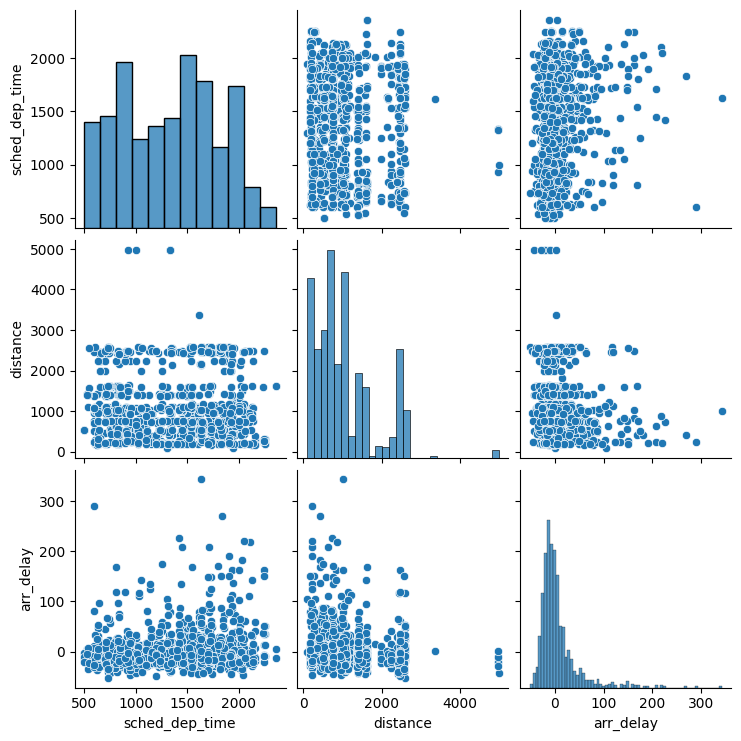

In [10]:
sns.pairplot(train_df[flight_num + target])

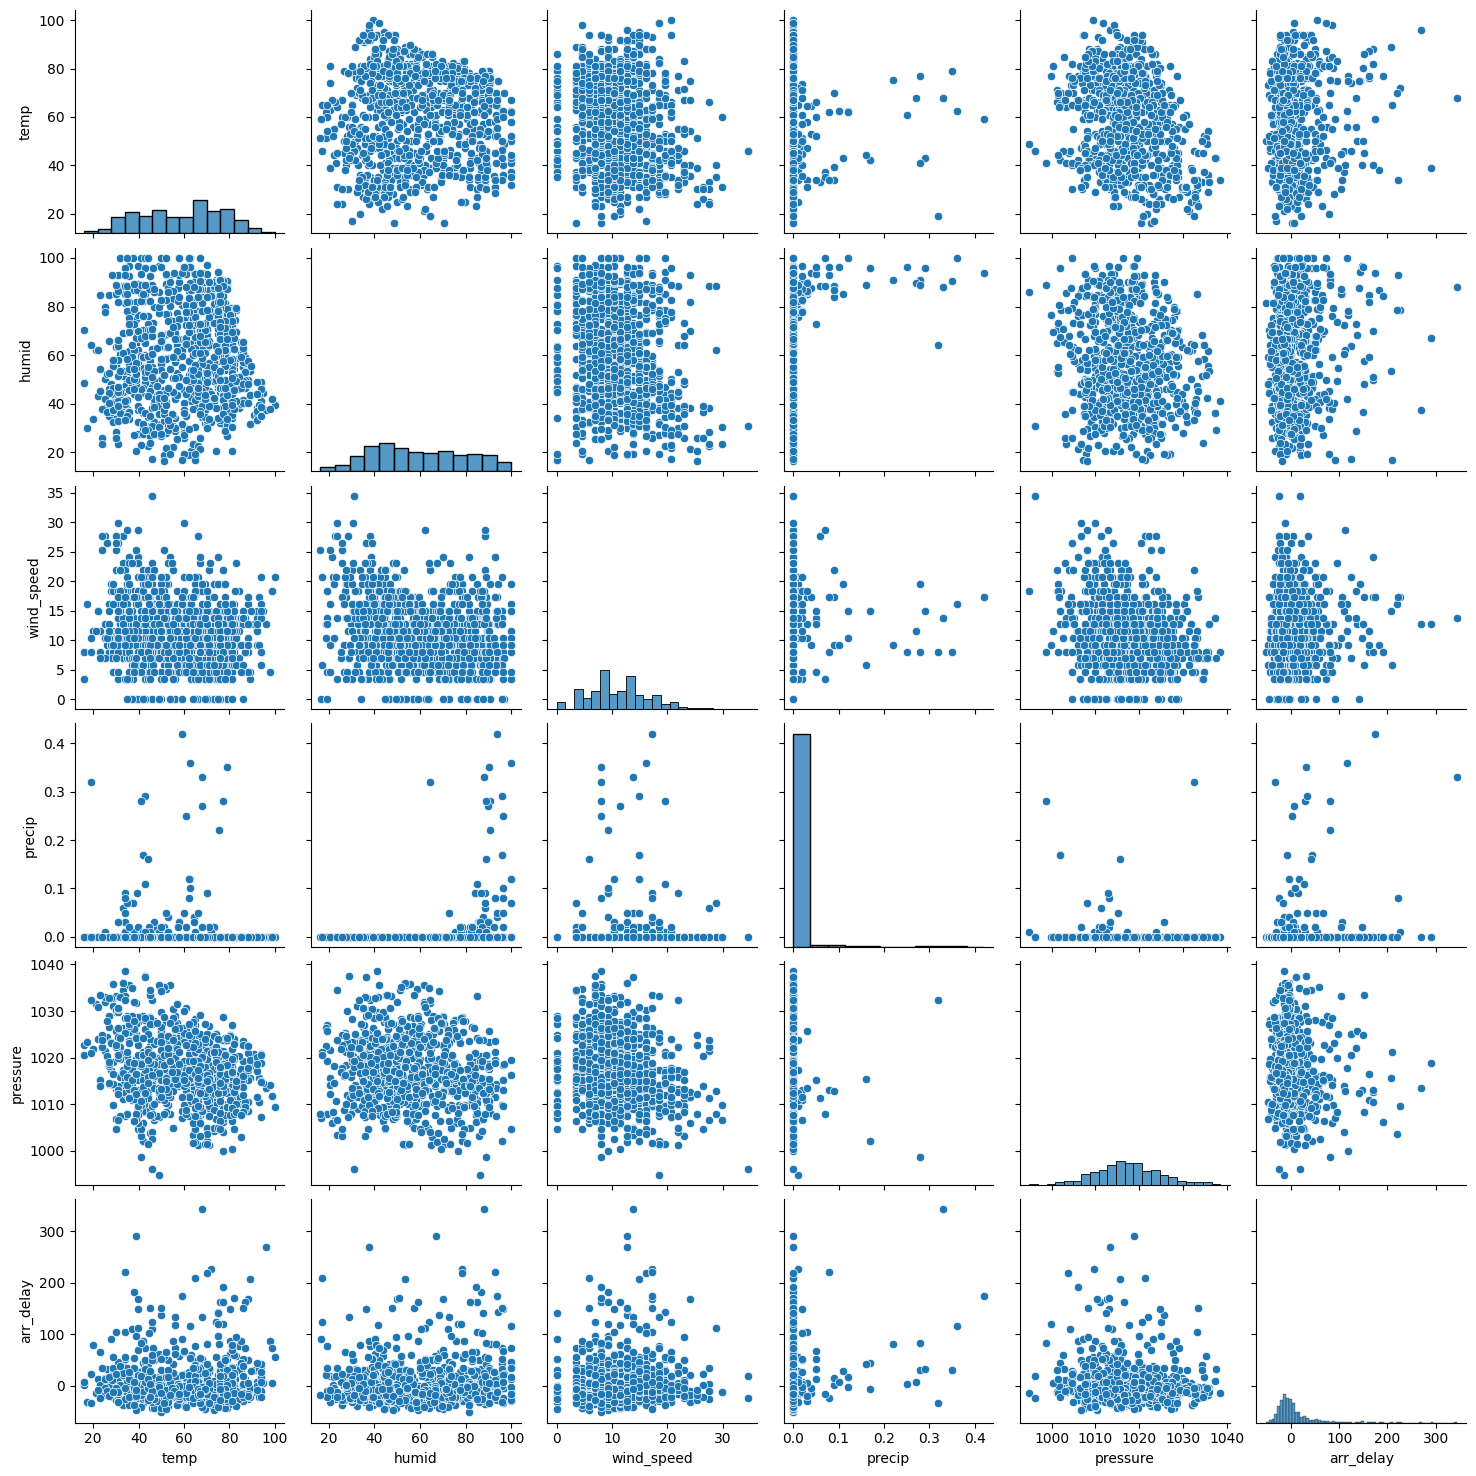

In [11]:
sns.pairplot(train_df[weather_num + target])

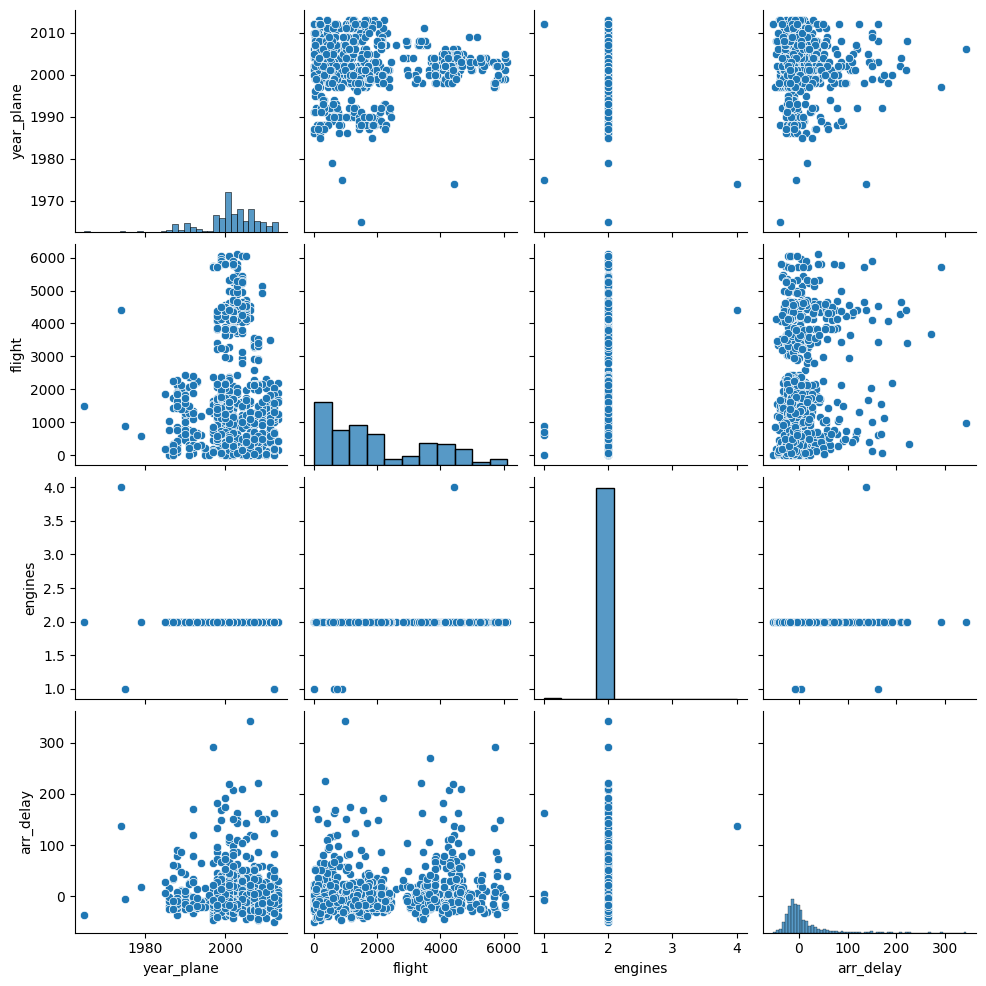

In [12]:
sns.pairplot(train_df[plane_num + plane_cat + target])

<Axes: >

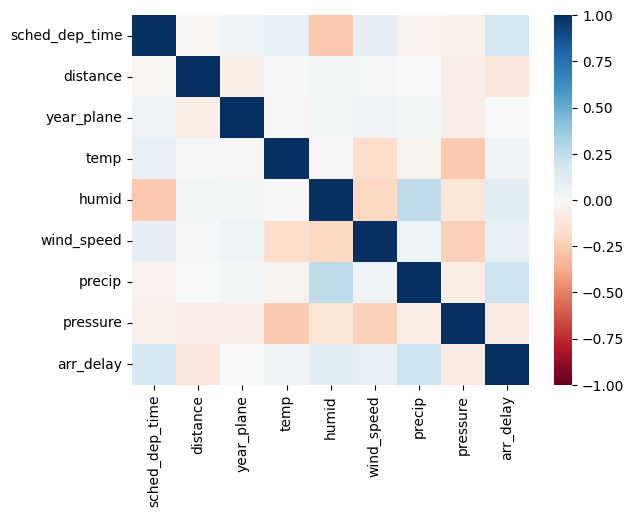

In [13]:
sns.heatmap(train_df[flight_num + plane_num + weather_num + target].corr(), vmin=-1, vmax=1, annot=False, cmap="RdBu")

In [14]:
train_df[flight_num + plane_num + weather_num + target].corr()

,sched_dep_time,distance,year_plane,temp,humid,wind_speed,precip,pressure,arr_delay
sched_dep_time,1.000000,-0.022115,0.061304,0.080645,-0.265689,0.095468,-0.041567,-0.052270,0.177985
distance,-0.022115,1.000000,-0.075330,0.009973,0.030832,0.022711,0.000780,-0.065223,-0.111011
year_plane,0.061304,-0.075330,1.000000,-0.008320,0.029681,0.049730,0.029365,-0.067237,0.002028
temp,0.080645,0.009973,-0.008320,1.000000,-0.006805,-0.186446,-0.034502,-0.265163,0.046027
humid,-0.265689,0.030832,0.029681,-0.006805,1.000000,-0.205084,0.255898,-0.120836,0.109687
wind_speed,0.095468,0.022711,0.049730,-0.186446,-0.205084,1.000000,0.054205,-0.239453,0.091267
precip,-0.041567,0.000780,0.029365,-0.034502,0.255898,0.054205,1.000000,-0.075445,0.215670
pressure,-0.052270,-0.065223,-0.067237,-0.265163,-0.120836,-0.239453,-0.075445,1.000000,-0.086949
arr_delay,0.177985,-0.111011,0.002028,0.046027,0.109687,0.091267,0.215670,-0.086949,1.000000
